In [25]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" #to accept differences in library versions accross imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import fastmri
from fastmri.data import transforms as T
from fastmri.data.subsample import RandomMaskFunc

In [2]:
file_path = r"D:\fastMRI\multicoil_train\2022061001_FLAIR01.h5"

with h5py.File(file_path, "r") as hf:
    slice_idx = hf["kspace"].shape[0] // 2
    slice_kspace = hf["kspace"][slice_idx]
    slice_rss = hf["reconstruction_rss"][slice_idx]

print("slice_kspace shape:", slice_kspace.shape)   #(no. of slices, no. of coils, spatial frequency points, spatial phase points)
print("slice_rss shape:", slice_rss.shape)         #(no. of slices, spatial frequency points, spatial phase points) ---> per coil

slice_kspace shape: (4, 256, 256)
slice_rss shape: (256, 256)


In [3]:
slice_kspace_t = T.to_tensor(slice_kspace)
print("tensor shape:", slice_kspace_t.shape)  #convert numpy array into a pytorch tensor

tensor shape: torch.Size([4, 256, 256, 2])


In [4]:
mask_func = RandomMaskFunc(
    center_fractions=[0.08],
    accelerations=[4]   #4x acceleration factor
)

In [5]:
masked_kspace, mask, num_low_frequencies = T.apply_mask(
    slice_kspace_t,
    mask_func,
    seed=42  #fix result
)

print("masked_kspace shape:", masked_kspace.shape)
print("mask shape:", mask.shape)
print("num_low_frequencies:", num_low_frequencies)

masked_kspace shape: torch.Size([4, 256, 256, 2])
mask shape: torch.Size([1, 1, 256, 1])
num_low_frequencies: 20


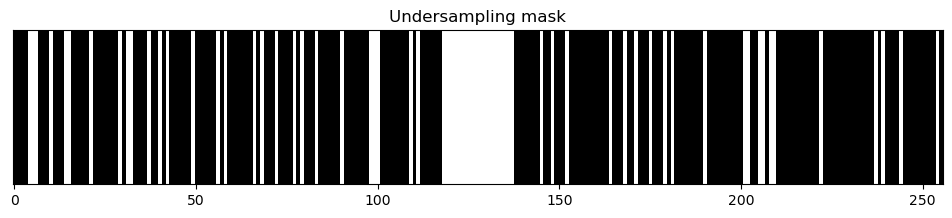

In [6]:
plt.figure(figsize=(12, 2))
plt.imshow(mask[0, 0, :, 0].cpu().numpy()[None, :], cmap="gray", aspect="auto")
plt.title("Undersampling mask")
plt.yticks([])
plt.show()    #keep central mask in full, sparse the outer k-space

In [7]:
full_img = fastmri.ifft2c(slice_kspace_t)
full_abs = fastmri.complex_abs(full_img)
full_rss = fastmri.rss(full_abs, dim=0)  #reconstruct the fully sampled k space

In [8]:
zf_img = fastmri.ifft2c(masked_kspace)
zf_abs = fastmri.complex_abs(zf_img)
zf_rss = fastmri.rss(zf_abs, dim=0)      #reconstruct the undersampled k space

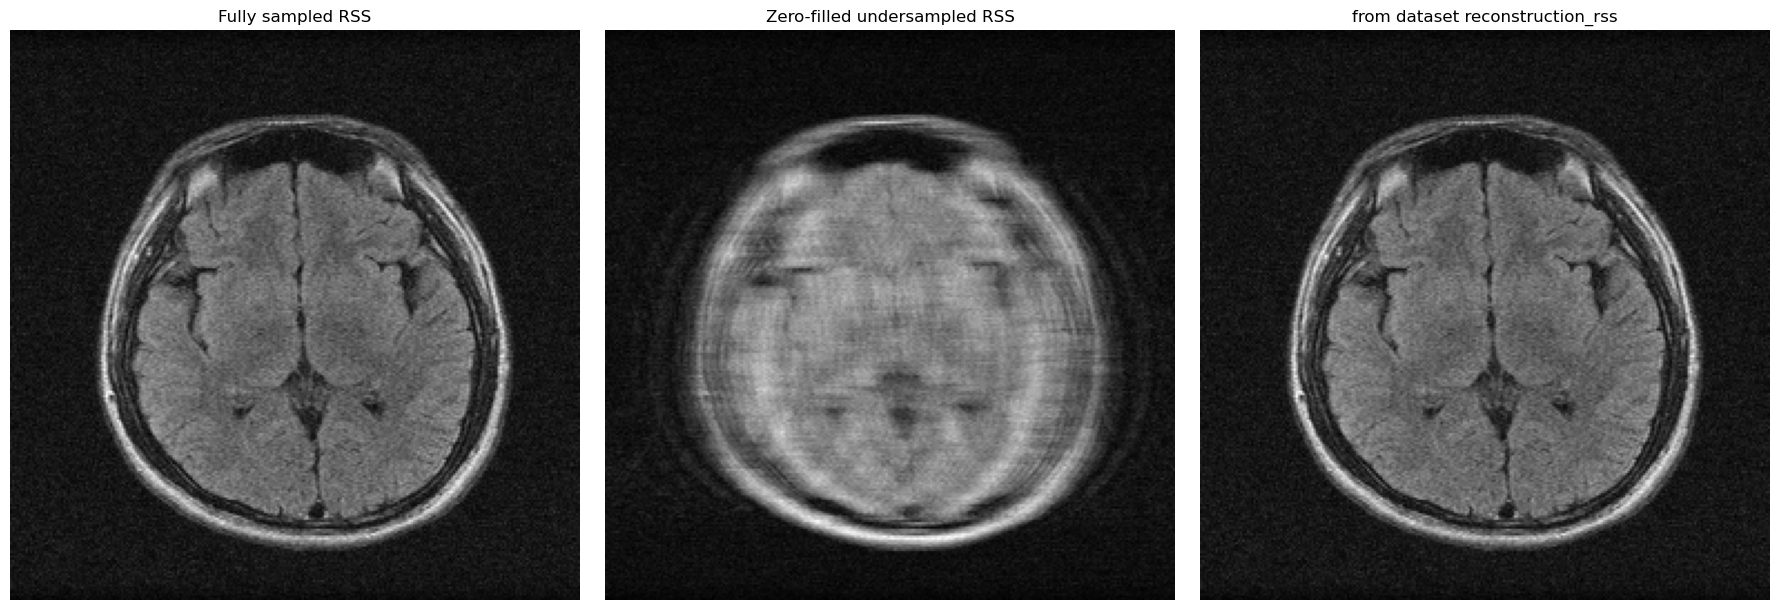

In [9]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(full_rss.numpy(), cmap="gray")
plt.title("Fully sampled RSS")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(zf_rss.numpy(), cmap="gray")
plt.title("Zero-filled undersampled RSS")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(slice_rss, cmap="gray")
plt.title("from dataset reconstruction_rss")
plt.axis("off")

plt.tight_layout()
plt.show()

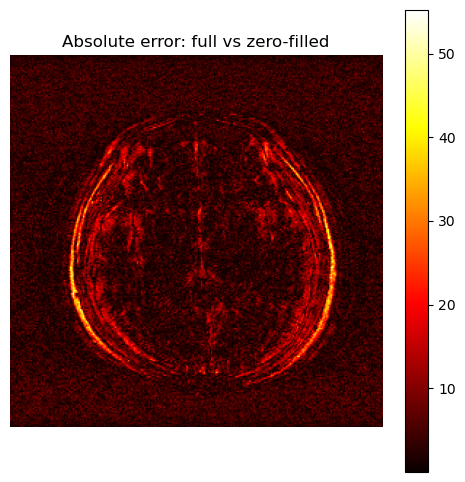

In [10]:
diff = np.abs(full_rss.numpy() - zf_rss.numpy())

plt.figure(figsize=(6, 6))
plt.imshow(diff, cmap="hot")
plt.title("Absolute error: full vs zero-filled")
plt.axis("off")
plt.colorbar()
plt.show()

# U-Net training (CNN-based)
input is artifact corrupted zero-filled images, and target is the dataset reconstructed RSS image

it cannot work on k-space domain, they instead reconstruct images to better slices after the training

In [11]:
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split   #pytorch for training unet, fastMRI for sampling, recon

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = r"D:\fastMRI\multicoil_train"
files = sorted(glob.glob(os.path.join(data_dir, "*.h5")))
print("num files:", len(files))
print(files[:3])

Device: cpu
num files: 1024
['D:\\fastMRI\\multicoil_train\\2022061001_FLAIR01.h5', 'D:\\fastMRI\\multicoil_train\\2022061001_FLAIR02.h5', 'D:\\fastMRI\\multicoil_train\\2022061001_T101.h5']


In [13]:
def normalize_image(img):
    img = img.astype(np.float32)
    img = img - img.min()   #create negative
    if img.max() > 0:
        img = img / img.max()   #normalize
    return img

In [14]:
class MRISliceDataset(Dataset):
    def __init__(self, file_list, center_fraction=0.08, acceleration=4, max_slices_per_file=None):
        self.file_list = file_list
        self.mask_func = RandomMaskFunc(
            center_fractions=[center_fraction],
            accelerations=[acceleration]
        )
        self.examples = []

        for fp in self.file_list:
            with h5py.File(fp, "r") as hf:
                num_slices = hf["kspace"].shape[0]
            if max_slices_per_file is None:
                slice_ids = range(num_slices)
            else:
                slice_ids = range(min(num_slices, max_slices_per_file))
            for s in slice_ids:
                self.examples.append((fp, s))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        fp, s = self.examples[idx]

        with h5py.File(fp, "r") as hf:
            kspace = hf["kspace"][s]
            target = hf["reconstruction_rss"][s]

        kspace_t = T.to_tensor(kspace)  #convert to a tensor

        masked_kspace, mask, num_low_frequencies = T.apply_mask(
            kspace_t, self.mask_func, seed=42
        )

        zf_img = fastmri.ifft2c(masked_kspace)   #perform mathematical reconstruction (signal processing)
        zf_abs = fastmri.complex_abs(zf_img)
        zf_rss = fastmri.rss(zf_abs, dim=0).numpy()

        zf_rss = normalize_image(zf_rss)
        target = normalize_image(target)

        zf_rss = torch.tensor(zf_rss, dtype=torch.float32).unsqueeze(0)
        target = torch.tensor(target, dtype=torch.float32).unsqueeze(0)

        return zf_rss, target

In [15]:
small_files = files[:50]   #start small for debugging
dataset = MRISliceDataset(small_files, center_fraction=0.08, acceleration=4, max_slices_per_file=18)

print("dataset size:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

x, y = dataset[0]
print("input shape:", x.shape)
print("target shape:", y.shape)

dataset size: 900
input shape: torch.Size([1, 256, 256])
target shape: torch.Size([1, 256, 256])


In [16]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),   #apply 2D mask/ kernel to image 
            nn.ReLU(inplace=True),                     
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)


    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        b = self.bridge(self.pool2(d2))

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.out(u1)           #structure for U-Net: encoder, decoder and skip connections

In [17]:
model = UNetSmall().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(sum(p.numel() for p in model.parameters() if p.requires_grad))

465953


In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

In [19]:
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

Epoch 1/10 | train loss: 0.0443 | val loss: 0.0409
Epoch 2/10 | train loss: 0.0408 | val loss: 0.0392
Epoch 3/10 | train loss: 0.0393 | val loss: 0.0378
Epoch 4/10 | train loss: 0.0385 | val loss: 0.0407
Epoch 5/10 | train loss: 0.0382 | val loss: 0.0371
Epoch 6/10 | train loss: 0.0378 | val loss: 0.0377
Epoch 7/10 | train loss: 0.0374 | val loss: 0.0366
Epoch 8/10 | train loss: 0.0371 | val loss: 0.0364
Epoch 9/10 | train loss: 0.0373 | val loss: 0.0378
Epoch 10/10 | train loss: 0.0365 | val loss: 0.0367


In [20]:
from skimage.metrics import structural_similarity as ssim
def compute_psnr(a, b, data_range=1.0):
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return 100.0
    return 20 * np.log10(data_range / np.sqrt(mse))

In [23]:
#model validation
model.eval()
psnr_in, psnr_out, ssim_in, ssim_out = [], [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x).clamp(0, 1)

        x_np = x[0, 0].cpu().numpy()
        y_np = y[0, 0].cpu().numpy()
        p_np = pred[0, 0].cpu().numpy()

        psnr_in.append(compute_psnr(x_np, y_np))
        psnr_out.append(compute_psnr(p_np, y_np))
        ssim_in.append(ssim(x_np, y_np, data_range=1.0))
        ssim_out.append(ssim(p_np, y_np, data_range=1.0))

print("Zero-filled PSNR:", np.mean(psnr_in))
print("U-Net PSNR:", np.mean(psnr_out))
print("Zero-filled SSIM:", np.mean(ssim_in))
print("U-Net SSIM:", np.mean(ssim_out))

Zero-filled PSNR: 22.786173
U-Net PSNR: 25.11787
Zero-filled SSIM: 0.5999227068701197
U-Net SSIM: 0.6548593952366112


In [26]:
zf_psnr = 22.952797
unet_psnr = 27.110397
zf_ssim = 0.6004373584413021
unet_ssim = 0.690298641275906

results_df = pd.DataFrame({
    "Model": ["Zero-filled 4x", "U-Net 4x"],
    "PSNR": [zf_psnr, unet_psnr],
    "SSIM": [zf_ssim, unet_ssim]
})

results_df["PSNR"] = results_df["PSNR"].round(3)
results_df["SSIM"] = results_df["SSIM"].round(4)

improvement_df = pd.DataFrame({
    "Metric": ["PSNR", "SSIM"],
    "Baseline": [zf_psnr, zf_ssim],
    "U-Net": [unet_psnr, unet_ssim],
    "Absolute Improvement": [unet_psnr - zf_psnr, unet_ssim - zf_ssim]
})

improvement_df["Baseline"] = improvement_df["Baseline"].round(4)
improvement_df["U-Net"] = improvement_df["U-Net"].round(4)
improvement_df["Absolute Improvement"] = improvement_df["Absolute Improvement"].round(4)

display(results_df)
display(improvement_df)

print("\nResults table:\n")
print(results_df.to_markdown(index=False))

print("\nImprovement table:\n")
print(improvement_df.to_markdown(index=False))

,Model,PSNR,SSIM
0,Zero-filled 4x,22.953,0.6004
1,U-Net 4x,27.110,0.6903


,Metric,Baseline,U-Net,Absolute Improvement
0,PSNR,22.9528,27.1104,4.1576
1,SSIM,0.6004,0.6903,0.0899



Results table:

| Model          |   PSNR |   SSIM |
|:---------------|-------:|-------:|
| Zero-filled 4x | 22.953 | 0.6004 |
| U-Net 4x       | 27.11  | 0.6903 |

Improvement table:

| Metric   |   Baseline |   U-Net |   Absolute Improvement |
|:---------|-----------:|--------:|-----------------------:|
| PSNR     |    22.9528 | 27.1104 |                 4.1576 |
| SSIM     |     0.6004 |  0.6903 |                 0.0899 |


In [27]:
save_path = "unet_small_fastmri_4x.pth"
torch.save(model.state_dict(), save_path)
print("Saved:", save_path)

Saved: unet_small_fastmri_4x.pth


# Residual U-net

In a regular U-Net block, the network learns a full transformation from input features to output features. In a residual block, the network learns a correction on top of the input using a shortcut path. Good for improving gradient flow and training stability.

In [27]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1),
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class ResUNetSmall(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ResidualBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = ResidualBlock(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bridge(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out(d1)
        return out

In [30]:
resunet_model = ResUNetSmall().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(resunet_model.parameters(), lr=1e-3)

In [31]:
num_epochs = 10
train_losses_res = []
val_losses_res = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(resunet_model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(resunet_model, val_loader, criterion, device)

    train_losses_res.append(train_loss)
    val_losses_res.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

Epoch 1/10 | train loss: 0.0554 | val loss: 0.0422
Epoch 2/10 | train loss: 0.0383 | val loss: 0.0381
Epoch 3/10 | train loss: 0.0367 | val loss: 0.0358
Epoch 4/10 | train loss: 0.0354 | val loss: 0.0499
Epoch 5/10 | train loss: 0.0345 | val loss: 0.0420
Epoch 6/10 | train loss: 0.0335 | val loss: 0.0385
Epoch 7/10 | train loss: 0.0328 | val loss: 0.0358
Epoch 8/10 | train loss: 0.0328 | val loss: 0.0392
Epoch 9/10 | train loss: 0.0323 | val loss: 0.0413
Epoch 10/10 | train loss: 0.0323 | val loss: 0.0321


In [32]:
class ResUNetSmallGlobalResidual(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ResidualBlock(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = ResidualBlock(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ResidualBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ResidualBlock(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        inp = x

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bridge(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        correction = self.out(d1)
        return inp + correction

In [33]:
resunet_model.eval()
psnr_in, psnr_out, ssim_in, ssim_out = [], [], [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        pred = resunet_model(x).clamp(0, 1)

        x_np = x[0, 0].cpu().numpy()
        y_np = y[0, 0].cpu().numpy()
        p_np = pred[0, 0].cpu().numpy()

        psnr_in.append(compute_psnr(x_np, y_np))
        psnr_out.append(compute_psnr(p_np, y_np))
        ssim_in.append(ssim(x_np, y_np, data_range=1.0))
        ssim_out.append(ssim(p_np, y_np, data_range=1.0))

print("Zero-filled PSNR:", np.mean(psnr_in))
print("ResUNet PSNR:", np.mean(psnr_out))
print("Zero-filled SSIM:", np.mean(ssim_in))
print("ResUNet SSIM:", np.mean(ssim_out))

Zero-filled PSNR: 22.952797
ResUNet PSNR: 26.959766
Zero-filled SSIM: 0.6004373584413021
ResUNet SSIM: 0.6834642450364241


In [34]:

zf_psnr = 22.952797
unet_psnr = 27.110397
resunet_psnr = 26.959766

zf_ssim = 0.6004373584413021
unet_ssim = 0.690298641275906
resunet_ssim = 0.6834642450364241

results_df = pd.DataFrame({
    "Model": ["Zero-filled 4x", "U-Net 4x", "ResUNet 4x"],
    "PSNR": [zf_psnr, unet_psnr, resunet_psnr],
    "SSIM": [zf_ssim, unet_ssim, resunet_ssim]
})

results_df["PSNR"] = results_df["PSNR"].round(3)
results_df["SSIM"] = results_df["SSIM"].round(4)

improvement_df = pd.DataFrame({
    "Metric": ["PSNR", "SSIM"],
    "Baseline": [zf_psnr, zf_ssim],
    "U-Net": [unet_psnr, unet_ssim],
    "ResUNet": [resunet_psnr, resunet_ssim],
})

improvement_df["U-Net Abs Gain"] = [
    unet_psnr - zf_psnr,
    unet_ssim - zf_ssim
]
improvement_df["ResUNet Abs Gain"] = [
    resunet_psnr - zf_psnr,
    resunet_ssim - zf_ssim
]

improvement_df["U-Net % Gain"] = [
    100 * (unet_psnr - zf_psnr) / zf_psnr,
    100 * (unet_ssim - zf_ssim) / zf_ssim
]
improvement_df["ResUNet % Gain"] = [
    100 * (resunet_psnr - zf_psnr) / zf_psnr,
    100 * (resunet_ssim - zf_ssim) / zf_ssim
]

for col in ["Baseline", "U-Net", "ResUNet", "U-Net Abs Gain", "ResUNet Abs Gain", "U-Net % Gain", "ResUNet % Gain"]:
    improvement_df[col] = improvement_df[col].round(4)

display(results_df)
display(improvement_df)

print("\nResults table:\n")
print(results_df.to_markdown(index=False))

print("\nImprovement table:\n")
print(improvement_df.to_markdown(index=False))

,Model,PSNR,SSIM
0,Zero-filled 4x,22.953,0.6004
1,U-Net 4x,27.110,0.6903
2,ResUNet 4x,26.960,0.6835


,Metric,Baseline,U-Net,ResUNet,U-Net Abs Gain,ResUNet Abs Gain,U-Net % Gain,ResUNet % Gain
0,PSNR,22.9528,27.1104,26.9598,4.1576,4.007,18.1137,17.4574
1,SSIM,0.6004,0.6903,0.6835,0.0899,0.083,14.9660,13.8277



Results table:

| Model          |   PSNR |   SSIM |
|:---------------|-------:|-------:|
| Zero-filled 4x | 22.953 | 0.6004 |
| U-Net 4x       | 27.11  | 0.6903 |
| ResUNet 4x     | 26.96  | 0.6835 |

Improvement table:

| Metric   |   Baseline |   U-Net |   ResUNet |   U-Net Abs Gain |   ResUNet Abs Gain |   U-Net % Gain |   ResUNet % Gain |
|:---------|-----------:|--------:|----------:|-----------------:|-------------------:|---------------:|-----------------:|
| PSNR     |    22.9528 | 27.1104 |   26.9598 |           4.1576 |              4.007 |        18.1137 |          17.4574 |
| SSIM     |     0.6004 |  0.6903 |    0.6835 |           0.0899 |              0.083 |        14.966  |          13.8277 |


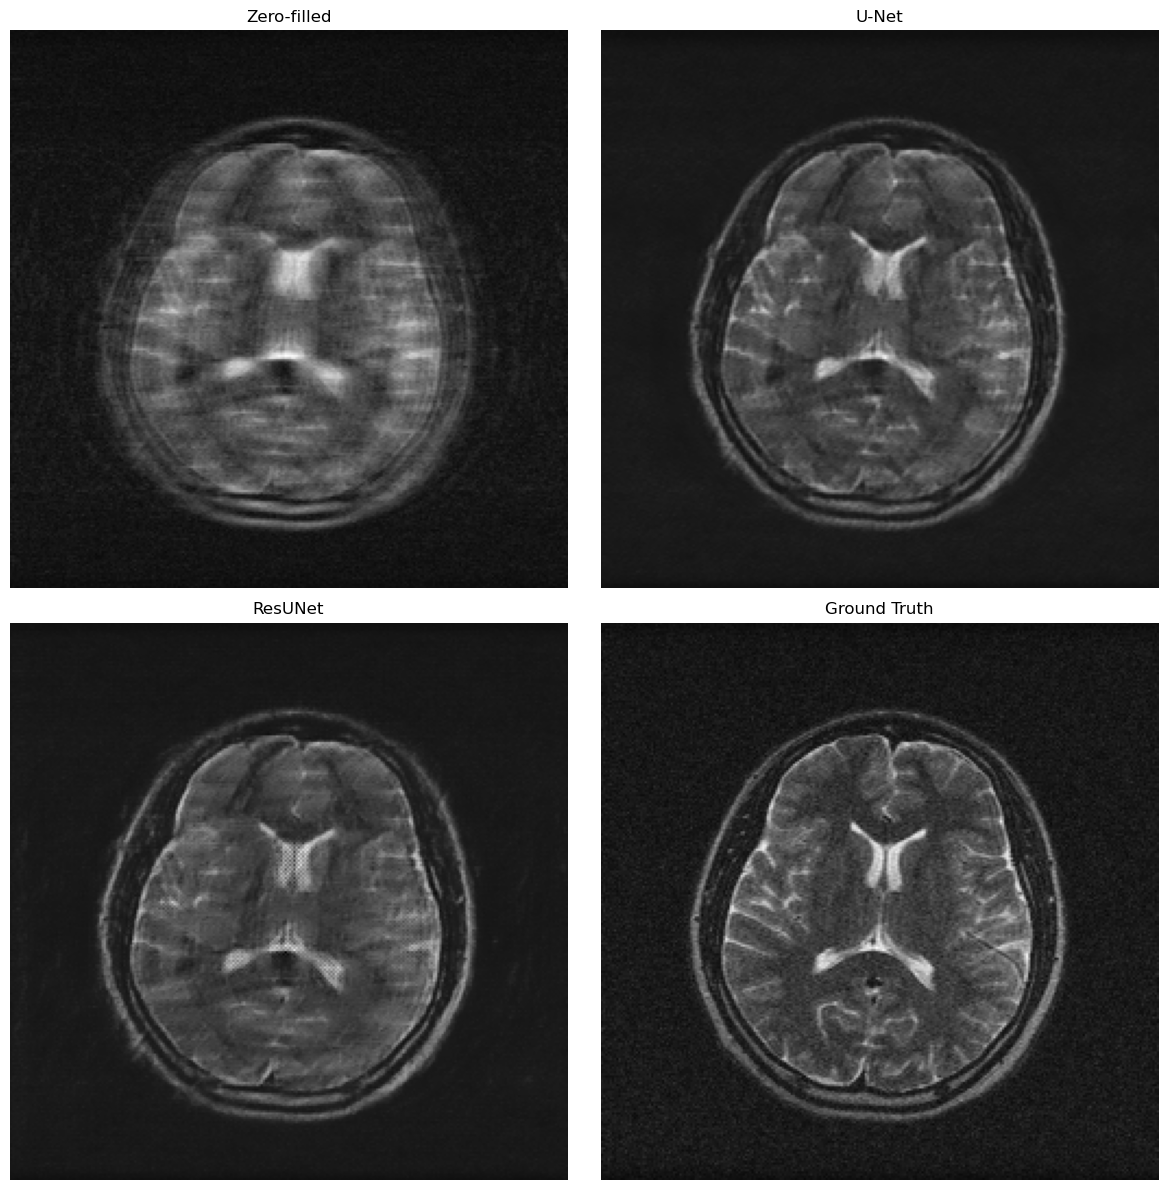

In [36]:
model.eval()
resunet_model.eval()

x, y = next(iter(val_loader))
x = x.to(device)
y = y.to(device)

with torch.no_grad():
    unet_pred = model(x)
    resunet_pred = resunet_model(x)

idx = 0

zf_img = x[idx, 0].detach().cpu().numpy()
unet_img = unet_pred[idx, 0].detach().cpu().numpy()
resunet_img = resunet_pred[idx, 0].detach().cpu().numpy()
gt_img = y[idx, 0].detach().cpu().numpy()

vmin = min(zf_img.min(), unet_img.min(), resunet_img.min(), gt_img.min())
vmax = max(zf_img.max(), unet_img.max(), resunet_img.max(), gt_img.max())

plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.imshow(zf_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Zero-filled")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(unet_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("U-Net")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(resunet_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("ResUNet")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gt_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

### Experimental Configuration

- Dataset: fastMRI multicoil brain MRI
- Input: zero-filled RSS reconstruction from 4× undersampled k-space
- Target: fully sampled `reconstruction_rss`
- Center fraction: 0.08
- Acceleration factor: 4×
- Training/validation split: 80/20
- Batch size: 4
- Loss: L1 loss
- Evaluation metrics: PSNR and SSIM
- Results reported on: the fixed validation subset used in this notebook

## Results Summary

Both learned reconstruction models improved substantially over the zero-filled 4× baseline. The zero-filled input achieved a PSNR of 22.953 and an SSIM of 0.6004.

The regular U-Net achieved the best performance, with a PSNR of 27.110 and an SSIM of 0.6903. This corresponds to an absolute improvement of 4.1576 dB in PSNR and 0.0899 in SSIM over the zero-filled baseline.

The ResUNet also improved over the zero-filled reconstruction, reaching a PSNR of 26.960 and an SSIM of 0.6835. However, it performed slightly below the regular U-Net, with improvements of 4.0070 dB in PSNR and 0.0830 in SSIM.

These results suggest that, under the current dataset subset, preprocessing, training schedule, and model capacity, the regular U-Net provided the strongest reconstruction performance. The ResUNet architecture did not produce an improvement in this experiment, but it remains a useful comparison showing that a more complex residual design is not automatically better.